# Yield Dataset Cleaning and Preprocessing

This notebook cleans the India agriculture yield dataset and prepares train/test splits for regression tasks with `random_state=42`.

In [4]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import zscore
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
ROOT = Path('..').resolve()
RAW_PATH = ROOT / 'data' / 'raw' / 'crop_yield.csv'
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR = ROOT / 'models'
OUTPUTS_DIR = ROOT / 'outputs'
for path in [PROCESSED_DIR, MODELS_DIR, OUTPUTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

In [5]:
df = pd.read_csv(RAW_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)
display((df.isna().mean() * 100).sort_values(ascending=False).to_frame('missing_pct'))

Shape: (19689, 10)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crop,19689,55,Rice,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,19689.0,NaN,NaN,NaN,2009.127584,6.498099,1997.0,2004.0,2010.0,2015.0,2020.0
Season,19689,6,Kharif,8232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,19689,30,Karnataka,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,19689.0,NaN,NaN,NaN,179926.570308,732828.675888,0.5,1390.0,9317.0,75112.0,50808100.0
Production,19689.0,NaN,NaN,NaN,16435941.273097,263056839.812568,0.0,1393.0,13804.0,122718.0,6326000000.0
Annual_Rainfall,19689.0,NaN,NaN,NaN,1437.755177,816.909589,301.3,940.7,1247.6,1643.7,6552.7
Fertilizer,19689.0,NaN,NaN,NaN,24103312.448806,94946004.482527,54.17,188014.62,1234957.44,10003847.2,4835406877.0
Pesticide,19689.0,NaN,NaN,NaN,48848.353392,213287.35486,0.09,356.7,2421.9,20041.7,15750511.0
Yield,19689.0,NaN,NaN,NaN,79.954009,878.306193,0.0,0.6,1.03,2.388889,21105.0


,missing_pct
Crop,0.0
Crop_Year,0.0
Season,0.0
State,0.0
Area,0.0
Production,0.0
Annual_Rainfall,0.0
Fertilizer,0.0
Pesticide,0.0
Yield,0.0


## 1) Target Engineering and Validity Checks

In [6]:
df = df.copy()
df.columns = [c.strip() for c in df.columns]

# Compute yield when needed. Keep provided Yield if available and valid.
if 'Yield' not in df.columns:
    if {'Production', 'Area'}.issubset(df.columns):
        df['Yield'] = np.where(df['Area'] > 0, df['Production'] / df['Area'], np.nan)
    else:
        raise ValueError('Yield target missing and cannot be derived from Production/Area.')
else:
    if {'Production', 'Area'}.issubset(df.columns):
        derived = np.where(df['Area'] > 0, df['Production'] / df['Area'], np.nan)
        df['Yield'] = np.where(df['Yield'].isna(), derived, df['Yield'])

range_rules = {
    'Area': (0, np.inf),
    'Production': (0, np.inf),
    'Annual_Rainfall': (0, 15000),
    'Fertilizer': (0, np.inf),
    'Pesticide': (0, np.inf),
    'Yield': (0, np.inf),
}

for col, (low, high) in range_rules.items():
    if col not in df.columns:
        continue
    invalid_mask = (df[col] < low) | (df[col] > high)
    if invalid_mask.any():
        print(f'{col}: replacing {invalid_mask.sum()} invalid values with NaN')
        df.loc[invalid_mask, col] = np.nan

In [7]:
target_col = 'Yield'
feature_cols = [c for c in df.columns if c != target_col]
work_df = df[feature_cols + [target_col]].copy()

numeric_cols = work_df.select_dtypes(include=['number']).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
categorical_cols = work_df.select_dtypes(include=['object', 'category']).columns.tolist()

missing_pct = work_df.isna().mean() * 100
drop_cols = missing_pct[missing_pct > 20].index.tolist()
if drop_cols:
    print('Dropping columns (>20% missing):', drop_cols)
    work_df = work_df.drop(columns=drop_cols)
    numeric_cols = [c for c in numeric_cols if c not in drop_cols]
    categorical_cols = [c for c in categorical_cols if c not in drop_cols]

low_missing_num = [c for c in numeric_cols if 0 < missing_pct[c] <= 5]
high_missing_num = [c for c in numeric_cols if missing_pct[c] > 5]

if low_missing_num:
    knn = KNNImputer(n_neighbors=5)
    work_df[low_missing_num] = knn.fit_transform(work_df[low_missing_num])
for col in high_missing_num:
    work_df[col] = work_df[col].fillna(work_df[col].median())

for col in categorical_cols:
    mode = work_df[col].mode(dropna=True)
    work_df[col] = work_df[col].fillna(mode.iloc[0] if len(mode) else 'missing')

work_df[target_col] = work_df[target_col].fillna(work_df[target_col].median())
display((work_df.isna().mean() * 100).to_frame('missing_pct_after'))

,missing_pct_after
Crop,0.0
Crop_Year,0.0
Season,0.0
State,0.0
Area,0.0
Production,0.0
Annual_Rainfall,0.0
Fertilizer,0.0
Pesticide,0.0
Yield,0.0


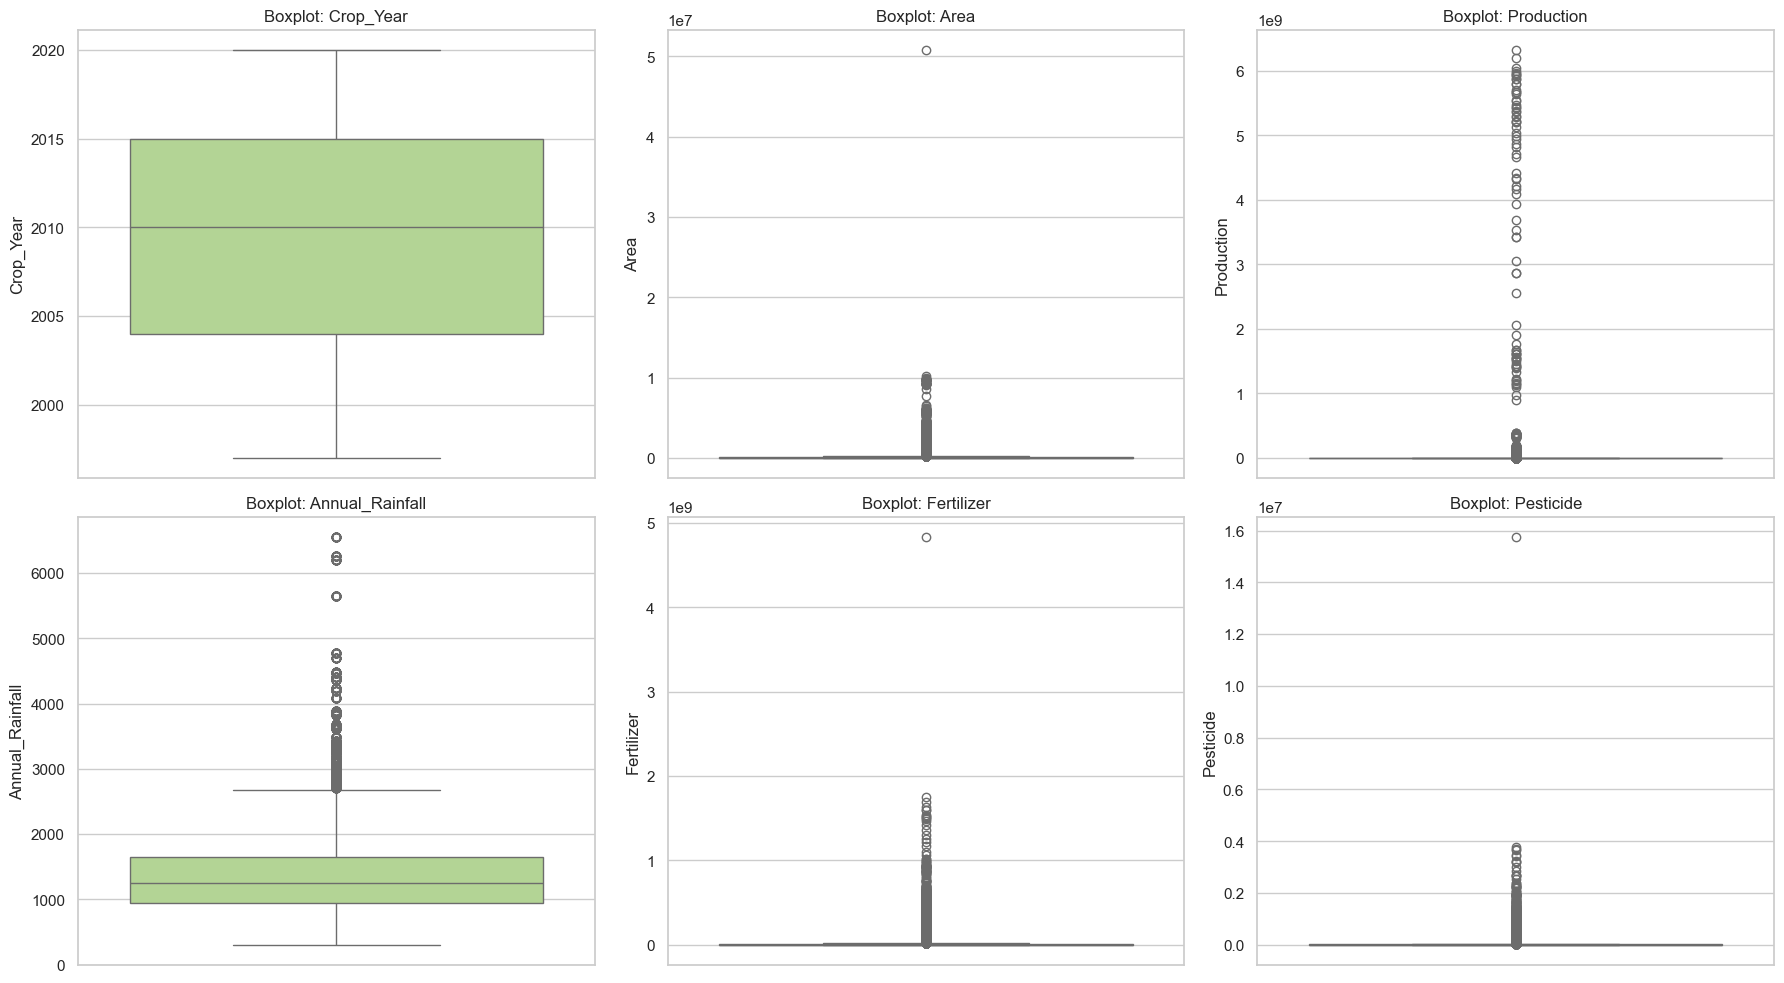

,zscore_outliers_gt3
Fertilizer,354
Area,347
Annual_Rainfall,303
Pesticide,299
Production,80
Crop_Year,0


In [8]:
fig, axes = plt.subplots(max(1, (len(numeric_cols)+2)//3), 3, figsize=(18, 5 * max(1, (len(numeric_cols)+2)//3)))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=work_df[col], ax=axes[i], color='#b2df8a')
    axes[i].set_title(f'Boxplot: {col}')
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

outlier_counts = {}
for col in numeric_cols:
    z_vals = np.abs(zscore(work_df[col], nan_policy='omit'))
    outlier_counts[col] = int((z_vals > 3).sum())
display(pd.Series(outlier_counts).sort_values(ascending=False).to_frame('zscore_outliers_gt3'))

# Cautious outlier treatment: IQR capping preserves extreme-event records without dropping rows.
for col in numeric_cols + [target_col]:
    q1 = work_df[col].quantile(0.25)
    q3 = work_df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    work_df[col] = work_df[col].clip(low, high)

## 2) Season Merging


In [11]:
# Merging (Autumn & Kharif) && (Winter & Rabi)

season_map = {
    'Autumn     ':'Kharif',
    'Winter     ':'Rabi',
    'Whole Year ':'Whole Year',
    'Kharif     ':'Kharif',
    'Rabi       ':'Rabi',
    'Summer     ':'Summer'
}

work_df['Season'] = work_df['Season'].replace(season_map)
work_df['Season'].value_counts()


Season
Kharif        8646
Rabi          6131
Whole Year    3717
Summer        1195
Name: count, dtype: int64

## 3) Split, Encoding Strategy Comparison, and Scaling

We compare one-hot vs ordinal encoding using the same RandomForest regressor and select the better approach on holdout $R^2$.

In [12]:
X = work_df.drop(columns=[target_col])
y = work_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

onehot_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ]
)

ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ]
)

pipe_onehot = Pipeline([
    ('prep', onehot_preprocessor),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])
pipe_ordinal = Pipeline([
    ('prep', ordinal_preprocessor),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])

pipe_onehot.fit(X_train, y_train)
pipe_ordinal.fit(X_train, y_train)

r2_onehot = r2_score(y_test, pipe_onehot.predict(X_test))
r2_ordinal = r2_score(y_test, pipe_ordinal.predict(X_test))

print({'onehot_r2': r2_onehot, 'ordinal_r2': r2_ordinal})
best_name = 'onehot' if r2_onehot >= r2_ordinal else 'ordinal'
best_pipe = pipe_onehot if best_name == 'onehot' else pipe_ordinal
print('Selected encoding strategy:', best_name)

joblib.dump(best_pipe, MODELS_DIR / 'yield_rf_preprocessing_pipeline.joblib')

pd.concat([X_train, y_train], axis=1).to_csv(PROCESSED_DIR / 'yield_train_raw.csv', index=False)
pd.concat([X_test, y_test], axis=1).to_csv(PROCESSED_DIR / 'yield_test_raw.csv', index=False)

results = pd.DataFrame({'encoding': ['onehot', 'ordinal'], 'r2': [r2_onehot, r2_ordinal]})
results.to_csv(OUTPUTS_DIR / 'yield_encoding_comparison.csv', index=False)
display(results)

{'onehot_r2': 0.9623073057859476, 'ordinal_r2': 0.9747459757280443}
Selected encoding strategy: ordinal


,encoding,r2
0,onehot,0.962307
1,ordinal,0.974746


## Rationale Summary

- Yield target is retained or computed as `Production / Area` when needed.
- Missing values are handled with a mixed strategy based on missingness ratio.
- Outliers are capped rather than removed to preserve potential extreme-event observations.
- One-hot and ordinal encoding are empirically compared; better $R^2$ is selected.
- Train/test split is done before model fitting, and preprocessing is inside pipeline to prevent leakage.